# BOFA DATASET EXPLORATION & DATA ANALYSIS

Life of ML project:

1. understanding the problem statement 
2. data collection 
3. data checks to perform 
4. exploratory data anlysis 
5. data preprocessing 
6. model training 
7. model eval.


### 1) Problem statement

The problem statement - Using the datasets provided can you use ML to find athletes which appear to have anomalous biomakrer fingerprints indicative of Growth hormone misuse.

Aims to use different immunological assay biomarker measurements on over 6000 different olympic/national competing athletes to create population level baselines for anomaly detection (semi-supervised)

### 2) Data Collection

Provided by WADA accredited sources: Labs from around the UK. Preprocessed by Statisticians from the University of Kent and Clinicians from St Thomas 

The data consists of 4 seperate datasets, 3 unlabelled biomarker datasets using different immunological assays and 1 labelled dataset containing GH washout data



### 2.1) Import the Data and Any required Packages

In [18]:
import numpy as np 
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt 
import openpyxl
import xlrd 
from scipy import stats
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler


In [19]:
# 4 datasets
endo_df = pd.read_excel("C:/Users/jagmeet/bofa_data/data/260216 GH Endocrine data.xlsx")
bio_df1 = pd.read_excel("C:/Users/jagmeet/bofa_data/data/Daegu data.xlsx")
bio_haem_df = pd.read_excel("C:/Users/jagmeet/bofa_data/data/260211 Bioinformatics hGH Biomarker data.xlsx")

### 2.2) Analyse Haemolysed Data

View the haemolysed dataset: bio_haem_df : we want to see if the haemolysed samples affect biomarker assay measurements, if they do, they are biased and can not be used in the clean dataset for the models

In [20]:
# Clean gender representation
bio_haem_df["M-F"] = bio_haem_df["M-F"].astype(str).str.upper()
bio_haem_df["Gender_num"] = np.where(bio_haem_df["M-F"] == "M", 0, 1)

# Flag haemolysed samples based on validity notes
notes_col = "Notes re: sample validity"
bio_haem_df["Haemolysed"] = np.where(
    bio_haem_df[notes_col].astype(str).str.contains("Haemolysed", case=False, na=False),
    "Haemolysed",
    "Not Haemolysed",
)

EDA section of haem. dataset: Evaluate baseline cohort (from dataset) 

- observe distribution to identify potential sampling bias or extrapolation thresholds (>40).

C:\Users\jagmeet\AppData\Local\Temp\ipykernel_22096\460832985.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data = bio_haem_df, x = 'M-F', palette = 'Set2', ax = axes[0])


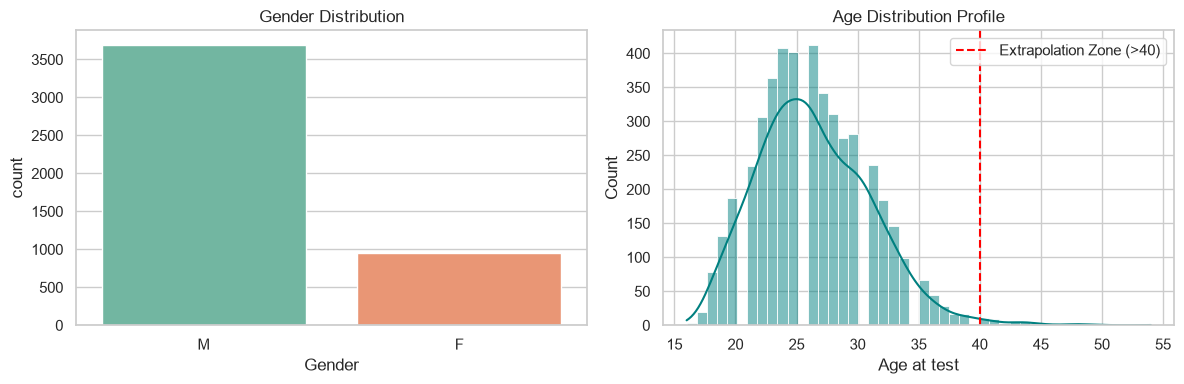

In [21]:
fig, axes = plt.subplots(1,2, figsize = (12, 4))
sns.countplot(data = bio_haem_df, x = 'M-F', palette = 'Set2', ax = axes[0])
axes[0].set_title("Gender Distribution")
axes[0].set_xlabel("Gender")

# 3B. Age histogram with threshold marker
sns.histplot(
    data=bio_haem_df, x="Age at test", kde=True, color="teal", ax=axes[1]
)
axes[1].axvline(40, color="red", linestyle="--", label="Extrapolation Zone (>40)")
axes[1].set_title("Age Distribution Profile")
axes[1].legend()

plt.tight_layout()
plt.show()

Stat. distribution analysis (K-S test) - kolmogorov-smirnov test (assumption of normality) = 2 sample test = (raw vs normalised)



In [22]:
clean_df = bio_haem_df[bio_haem_df["Haemolysed"] == "Not Haemolysed"].copy()
haem_df = bio_haem_df[bio_haem_df["Haemolysed"] == "Haemolysed"].copy()

print(" KOLMOGOROV-SMIRNOV TEST BELOW:")
for col in ['IGF-I Mean', 'PIIINP Mean']:
    # distribution test on raw values 
    stat_raw, p_raw = stats.ks_2samp(
        clean_df[col].dropna(), haem_df[col].dropna()
    )
    # distribution test on z-score normalized values 
    clean_z = stats.zscore(clean_df[col].dropna())
    haem_z = stats.zscore(haem_df[col].dropna())
    stat_norm, p_norm = stats.ks_2samp(clean_z, haem_z)
    print(
        f"{col:12s} | Raw p-val: {p_raw:.4e} | Normalized p-val: {p_norm:.4e}"
        ) 

 KOLMOGOROV-SMIRNOV TEST BELOW:
IGF-I Mean   | Raw p-val: 5.8710e-01 | Normalized p-val: 7.6523e-01
PIIINP Mean  | Raw p-val: 9.8134e-05 | Normalized p-val: 3.3699e-02


Confirmation with Mann-Whitney U test - On two indepenant datasets (Haemolysed vs Non-haemolysed)

additional Rank correlation test to measure the effect size

In [23]:

print("MANN-WHITNEY U TEST BELOW")

for col in ["IGF-I Mean", "PIIINP Mean", "GH Score"]:
    clean_vals = clean_df[col].dropna()
    haem_vals = haem_df[col].dropna()

    # 1. Mann-Whitney U Test (Independent 2-sample test)
    u_stat, p_val = stats.mannwhitneyu(clean_vals, haem_vals)

    # 2. Rank-Biserial Correlation (Effect Size measure)
    n1, n2 = len(clean_vals), len(haem_vals)
    r_bs = 1 - (2 * u_stat) / (n1 * n2)

    print(
        f"{col:12s} | U-Stat: {u_stat:8.1f} | p-val: {p_val:.4e} | Effect Size (r): {r_bs:.4f}"
    )

MANN-WHITNEY U TEST BELOW
IGF-I Mean   | U-Stat: 136741.5 | p-val: 4.0487e-01 | Effect Size (r): -0.0647
PIIINP Mean  | U-Stat: 161333.5 | p-val: 9.6870e-04 | Effect Size (r): -0.2561
GH Score     | U-Stat: 162585.5 | p-val: 6.1474e-04 | Effect Size (r): -0.2659


The Mann-Whitney U test confirms that haemolysis significantly impacts PIIINP Mean and downstream GH Score rank distributions (p < 0.001), while leaving IGF-I Mean relatively unaffected (p = 0.4049)

To remain on the 'SAFE SIDE' we will NOT being using the haemolysed dataset with the rest of the data on the model

### 2.3) Analyse Endocrine Data

In [24]:
# Descriptive Statistics: NA counts, shape, mean/median/mode/IQR of each numerical feature, M/F proportion

print(f"Shape: {endo_df.shape}")
print(endo_df.isnull().sum())

print("\n--- Summary Statistics ---")
print(endo_df.describe())
print(endo_df["Sport Gender"].value_counts())


Shape: (85, 9)
Sample Code                 0
igf-1: ng/mL(initial)       0
p-iii-np: ng/mL(initial)    0
Sport Gender                0
Date of test                0
Age at sample colln         0
Athlete ID                  0
Count Biomarkers            0
Count Endocrine             0
dtype: int64

--- Summary Statistics ---
       igf-1: ng/mL(initial)  p-iii-np: ng/mL(initial)  \
count              85.000000                 85.000000   
mean              192.659647                  7.763941   
min                54.650000                  1.275000   
25%               135.000000                  6.455000   
50%               181.550000                  7.690000   
75%               248.000000                  9.430000   
max               432.950000                 13.720000   
std                79.891257                  2.255613   

                     Date of test  Age at sample colln  Count Biomarkers  \
count                          85            85.000000         85.000000   

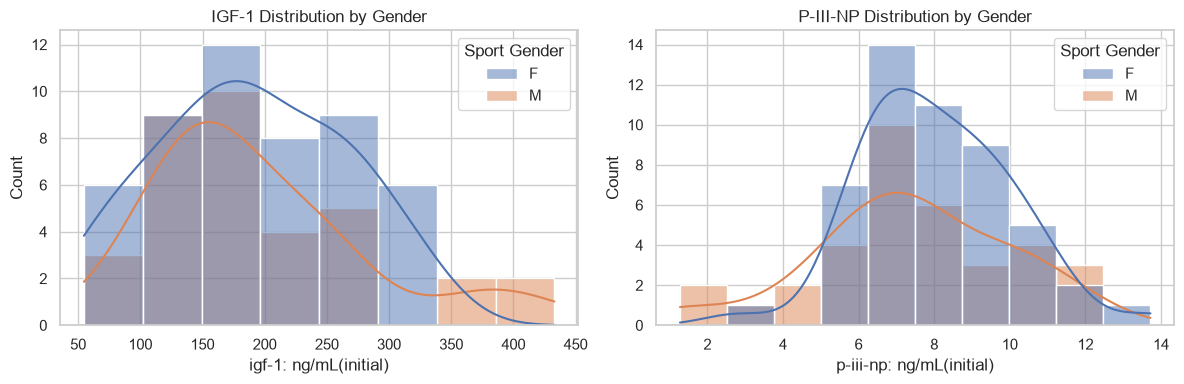

In [25]:
# Biomarker Distributions (Plots) - Gender Specific
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(
    data=endo_df,
    x="igf-1: ng/mL(initial)",
    hue="Sport Gender",
    kde=True,
    ax=axes[0],
)
axes[0].set_title("IGF-1 Distribution by Gender")

sns.histplot(
    data=endo_df,
    x="p-iii-np: ng/mL(initial)",
    hue="Sport Gender",
    kde=True,
    ax=axes[1],
)
axes[1].set_title("P-III-NP Distribution by Gender")

plt.tight_layout()
plt.show()

### 2.4) Analyse Biomarker Dataset 1

In [26]:
# Descriptive Statistics: NA counts, shape, mean/median/mode/IQR of each numerical feature, M/F proportion

print(f"Shape: {bio_df1.shape}")

# 2. Key Biomarker Columns Summary
key_daegu_cols = [
    "AGE (YEARS)",
    "Siemens PIIINP",
    "MS IGFI",
    "CIS PIIINP: (AVG)",
    "IMT: (AVG)",
    "ORION: (AVG)",
    "IDS IGFI: RESULT",
]

print("\n--- Missing Values in Key Biomarker Columns ---")
print(bio_df1[key_daegu_cols].isnull().sum())

print("\n--- Summary Statistics ---")
print(bio_df1[key_daegu_cols].describe())

print(bio_df1["SEX"].value_counts())


Shape: (1435, 49)

--- Missing Values in Key Biomarker Columns ---
AGE (YEARS)           0
Siemens PIIINP        3
MS IGFI               9
CIS PIIINP: (AVG)     9
IMT: (AVG)            0
ORION: (AVG)         12
IDS IGFI: RESULT      1
dtype: int64

--- Summary Statistics ---
       AGE (YEARS)  Siemens PIIINP      MS IGFI  CIS PIIINP: (AVG)  \
count  1435.000000     1432.000000  1426.000000        1426.000000   
mean     25.901045        6.657423   290.353326           1.006455   
std       4.289713        2.591473    91.766120           0.332392   
min      13.000000        1.100000    85.482009           0.314000   
25%      23.000000        5.090000   226.310887           0.790000   
50%      25.000000        6.215000   276.163345           0.951000   
75%      29.000000        7.640000   341.475497           1.176000   
max      47.000000       31.180000   736.906188           4.623000   

        IMT: (AVG)  ORION: (AVG)  IDS IGFI: RESULT  
count  1435.000000   1423.000000       1

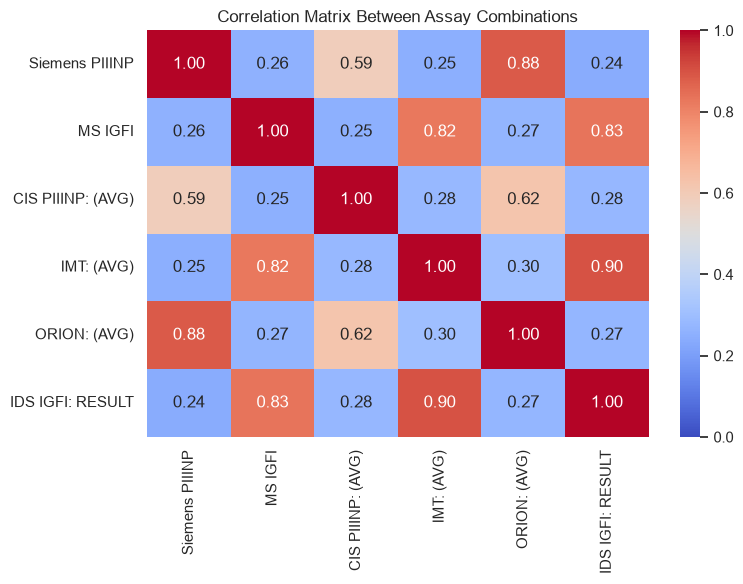

In [27]:
# use a correlation matrix to view combinations of assays and their correlation
assay_cols = [
    "Siemens PIIINP",
    "MS IGFI",
    "CIS PIIINP: (AVG)",
    "IMT: (AVG)",
    "ORION: (AVG)",
    "IDS IGFI: RESULT",
]
corr_matrix = bio_df1[assay_cols].corr()

# Plot heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix, annot=True, cmap="coolwarm", vmin=0, vmax=1, fmt=".2f"
)
plt.title("Correlation Matrix Between Assay Combinations")
plt.tight_layout()

plt.show()

### 2.5) Analyse GH control Dataset 

In [45]:
file_path = "C:/Users/jagmeet/bofa_data/data/Mar2012ForIEM_NGdecode_RNA GH admin study serum results(CB results).csv"
# Read raw sheet
raw_df = pd.read_csv(file_path)

# Extract and clean header row names from rows 1 to 3
data_df = raw_df.iloc[4:].copy()
data_df.columns = [
    "subject_id",
    "volunteer",
    "visit_day",
    "time_min",
    "CIS_PIIIP_u_mL",
    "ORION_PIIIP_ng_mL",
    "IMMULITE_IGFI_ng_mL",
    "IMMUNO_IGFI_ng_mL",
    "empty_col",
    "gender",
    "age_1",
    "age_2",
    "CIS_Immulite",
    "Orion_Immunotech",
    "Orion_Immulite",
    "CIS_Immunotech",
]

# Drop empty column and missing volunteer rows
data_df = data_df.drop(columns=["empty_col"]).dropna(subset=["volunteer"])

# Cast numeric columns
numeric_cols = [
    "visit_day",
    "time_min",
    "CIS_PIIIP_u_mL",
    "ORION_PIIIP_ng_mL",
    "IMMULITE_IGFI_ng_mL",
    "IMMUNO_IGFI_ng_mL",
    "age_1",
    "CIS_Immulite",
    "Orion_Immunotech",
    "Orion_Immulite",
    "CIS_Immunotech",
]

for col in numeric_cols:
    data_df[col] = pd.to_numeric(data_df[col], errors="coerce")

print("=" * 60)
print("1. DATASET OVERVIEW & MISSING VALUES")
print("=" * 60)
print(f"Total Observation Rows: {len(data_df)}")
print(f"Unique Volunteers: {data_df['volunteer'].nunique()}")
print(f"Volunteers List: {data_df['volunteer'].unique().tolist()}\n")

print("Missing values per column:")
print(data_df.isnull().sum())

print("\n" + "=" * 60)
print("2. NUMERICAL SUMMARY STATISTICS")
print("=" * 60)
stats = data_df[numeric_cols].describe().T
stats["skewness"] = data_df[numeric_cols].skew()
print(stats[["count", "mean", "std", "min", "25%", "50%", "75%", "max", "skewness"]])



1. DATASET OVERVIEW & MISSING VALUES
Total Observation Rows: 98
Unique Volunteers: 10
Volunteers List: ['RNAGH001', 'RNAGH003', 'RNAGH004', 'RNAGH005', 'RNAGH006', 'RNAGH007', 'RNAGH008', 'RNAGH010', 'RNAGH011', 'RNAGH012']

Missing values per column:
subject_id              0
volunteer               0
visit_day               0
time_min                0
CIS_PIIIP_u_mL         58
ORION_PIIIP_ng_mL       1
IMMULITE_IGFI_ng_mL    59
IMMUNO_IGFI_ng_mL       0
gender                  0
age_1                   0
age_2                   0
CIS_Immulite           59
Orion_Immunotech        1
Orion_Immulite         59
CIS_Immunotech         58
dtype: int64

2. NUMERICAL SUMMARY STATISTICS
                     count        mean         std        min         25%  \
visit_day             98.0    2.418367    2.260934    1.00000    1.000000   
time_min              98.0   94.591837  150.299827    0.00000    0.000000   
CIS_PIIIP_u_mL        40.0    0.419675    0.061396    0.27800    0.380750   
ORIO

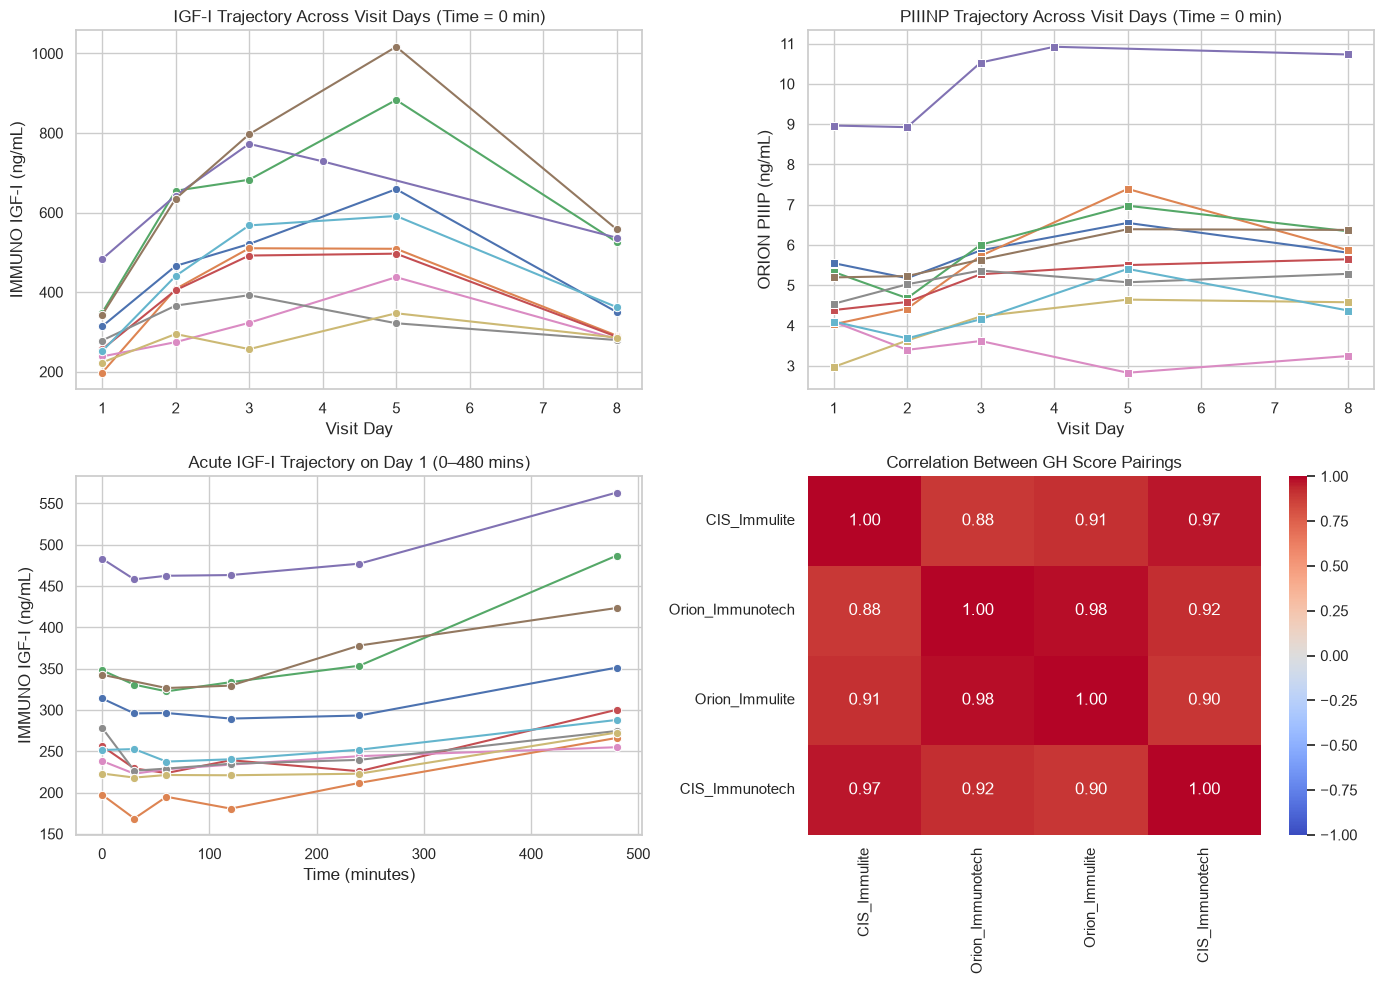

In [29]:
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Longitudinal IGF-I Response (Days 1–8 at baseline time 0)
day_0min = data_df[data_df["time_min"] == 0]
sns.lineplot(
    data=day_0min,
    x="visit_day",
    y="IMMUNO_IGFI_ng_mL",
    hue="volunteer",
    marker="o",
    ax=axes[0, 0],
    legend=False,
)
axes[0, 0].set_title("IGF-I Trajectory Across Visit Days (Time = 0 min)")
axes[0, 0].set_xlabel("Visit Day")
axes[0, 0].set_ylabel("IMMUNO IGF-I (ng/mL)")

# Plot 2: Longitudinal PIIINP Response (Days 1–8 at baseline time 0)
sns.lineplot(
    data=day_0min,
    x="visit_day",
    y="ORION_PIIIP_ng_mL",
    hue="volunteer",
    marker="s",
    ax=axes[0, 1],
    legend=False,
)
axes[0, 1].set_title("PIIINP Trajectory Across Visit Days (Time = 0 min)")
axes[0, 1].set_xlabel("Visit Day")
axes[0, 1].set_ylabel("ORION PIIIP (ng/mL)")

# Plot 3: Acute Day 1 Response (0 to 480 minutes)
day1_df = data_df[data_df["visit_day"] == 1]
sns.lineplot(
    data=day1_df,
    x="time_min",
    y="IMMUNO_IGFI_ng_mL",
    hue="volunteer",
    marker="o",
    ax=axes[1, 0],
    legend=False,
)
axes[1, 0].set_title("Acute IGF-I Trajectory on Day 1 (0–480 mins)")
axes[1, 0].set_xlabel("Time (minutes)")
axes[1, 0].set_ylabel("IMMUNO IGF-I (ng/mL)")

# Plot 4: Correlation between GH Formula Pairings
combo_cols = [
    "CIS_Immulite",
    "Orion_Immunotech",
    "Orion_Immulite",
    "CIS_Immunotech",
]
sns.heatmap(
    data_df[combo_cols].corr(),
    annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    fmt=".2f",
    ax=axes[1, 1],
)
axes[1, 1].set_title("Correlation Between GH Score Pairings")

plt.tight_layout()
plt.show()

### 2.6) Cleaning and Prepping Datasets for Models

Step-by-Step Data Cleaning Workflow ExplainedSchema Standardization & String Cleaning: 

Custom transformer developed to ensure that the data is standardized column=wise (z-score) independantly, within each unique assay/dataset group
 

In [38]:
import numpy as np
import pandas as pd
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer
from sklearn.pipeline import Pipeline
import os

In [ ]:
def sex_encoded(series):
    s_clean = series.astype(str).str.upper().str.strip() # remove all whitespace
    conditions = [
        series.isna(),
        s_clean.str.startswith('M'),
        s_clean.str.startswith('F')
    ]
    options = [np.nan, 1, 0]
    return np.select(conditions, options, default = np.nan)

def harmonize_raw_sources(df1_path, df2_path, df3_path, df4_path=None):
    """
    Reads raw Excel files and extracts standardized column structures.
    """
    df1 = pd.read_excel(df1_path)
    df2 = pd.read_excel(df2_path)
    df3 = pd.read_excel(df3_path)

    df1_clean = pd.DataFrame({
        'sample_id': df1['Sample Code'].astype(str),
        'igf1': pd.to_numeric(df1['igf-1: ng/mL(initial)'], errors='coerce'), # convert non-numerical values into numerical values (NAN to NAN numerical)
        'piiinp': pd.to_numeric(df1['p-iii-np: ng/mL(initial)'], errors='coerce'),
        'age': pd.to_numeric(df1['Age at sample colln'], errors='coerce'),
        'sex': sex_encoded(df1['Sport Gender']),
        'dataset_source': 'df1_endocrine',
        'target': -1
    })

    df2_clean = pd.DataFrame({
        'sample_id': df2['SAMPLE CODE'].astype(str),
        'igf1': pd.to_numeric(df2['MS IGFI'], errors='coerce'),
        'piiinp': pd.to_numeric(df2['Siemens PIIINP'], errors='coerce'),
        'age': pd.to_numeric(df2['AGE (YEARS)'], errors='coerce'),
        'sex': sex_encoded(df2['SEX']),
        'dataset_source': 'df2_daegu',
        'target': -1
    })

    df3_clean = pd.DataFrame({
        'sample_id': df3['Sample Code'].astype(str),
        'igf1': pd.to_numeric(df3['IGF-I Mean'], errors='coerce'),
        'piiinp': pd.to_numeric(df3['PIIINP Mean'], errors='coerce'),
        'age': pd.to_numeric(df3['Age at test'], errors='coerce'),
        'sex': sex_encoded(df3['M-F']),
        'dataset_source': 'df3_bio',
        'target': -1
    })

    datasets = [df1_clean, df2_clean, df3_clean]

    if df4_path:
        df4_raw = pd.read_csv(df4_path, sheet_name=0)
        df4_data = df4_raw.iloc[4:].copy()
        df4_clean = pd.DataFrame({
            'sample_id': df4_data.iloc[:, 0].astype(str),
            'igf1': pd.to_numeric(df4_data.iloc[:, 7], errors='coerce'),
            'piiinp': pd.to_numeric(df4_data.iloc[:, 5], errors='coerce'),
            'age': pd.to_numeric(df4_data.iloc[:, 10], errors='coerce'),
            'sex': sex_encoded(df4_data.iloc[:, 9]),
            'dataset_source': 'df4_gh_washout',
            'target': 1
        })
        datasets.append(df4_clean)

    return pd.concat(datasets, ignore_index=True)

In [42]:

class AssayZScoreScaler(BaseEstimator, TransformerMixin):
    """
    Custom transformer that standardizes columns (Z-score) 
    independently within each unique assay/dataset group.
    """
    def __init__(self, source_col='dataset_source'):
        self.source_col = source_col

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X_df = X.copy() if isinstance(X, pd.DataFrame) else pd.DataFrame(X) # convert to df
        
        # Calculate within-group Z-scores
        for col in ['log_igf1', 'log_piiinp']:
            if col in X_df.columns: # standard z score transformation of data columns which start with log
                X_df[f'z_{col.replace("log_", "")}'] = X_df.groupby(self.source_col)[col].transform(
                    lambda x: (x - x.mean()) / x.std(ddof=0) if x.std(ddof=0) > 0 else 0
                )
        
        # Derive relative biomarker ratio metric
        if 'z_igf1' in X_df.columns and 'z_piiinp' in X_df.columns:
            X_df['z_biomarker_ratio'] = X_df['z_igf1'] - X_df['z_piiinp']
            
        return X_df

class Log1pTransformer(BaseEstimator, TransformerMixin):
    """
    Applies log1p transformation to raw biomarker features.
    """
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X_df = X.copy()
        X_df['log_igf1'] = np.log1p(X_df['igf1'].clip(lower=0))
        X_df['log_piiinp'] = np.log1p(X_df['piiinp'].clip(lower=0))
        return X_df

In [ ]:
def create_preprocessing_pipeline():
    """
    Constructs a reproducible Pipeline for processing biomarker features.
    """
    preprocessing_pipeline = Pipeline(steps=[
        ('log_transform', Log1pTransformer()),
        ('assay_zscore', AssayZScoreScaler(source_col='dataset_source'))
    ])
    return preprocessing_pipeline

# 1. process Raw Data
data_dir = "C:/Users/jagmeet/bofa_data/data/"
df1_path = os.path.join(data_dir, "260216 GH Endocrine data.xlsx")
df2_path = os.path.join(data_dir, "Daegu data.xlsx")
df3_path = os.path.join(data_dir, "260211 Bioinformatics hGH Biomarker data.xlsx")
df4_path = os.path.join(data_dir, "Mar2012ForIEM_NGdecode_RNA GH admin study serum results(CB results).csv")

raw_combined_df = harmonize_raw_sources(df1_path, df2_path, df3_path, df4_path)

# 2. Fit and Transform Data using the Pipeline
prep_pipeline = create_preprocessing_pipeline()
combined_df = prep_pipeline.fit_transform(raw_combined_df)

# Output Summary Check
print(combined_df[['sample_id', 'dataset_source', 'z_igf1', 'z_piiinp', 'z_biomarker_ratio']].head())

  sample_id dataset_source    z_igf1  z_piiinp  z_biomarker_ratio
0    394626  df1_endocrine  0.779579 -0.874947           1.654526
1    925536  df1_endocrine  0.930762 -0.623864           1.554626
2   256802V  df1_endocrine  0.676150 -0.600722           1.276873
3   5805591  df1_endocrine -0.627731 -0.373719          -0.254011
4   5805878  df1_endocrine -0.156880 -0.682457           0.525577


In [ ]:
combined_df.to_csv('df_processed.csv', index=False)